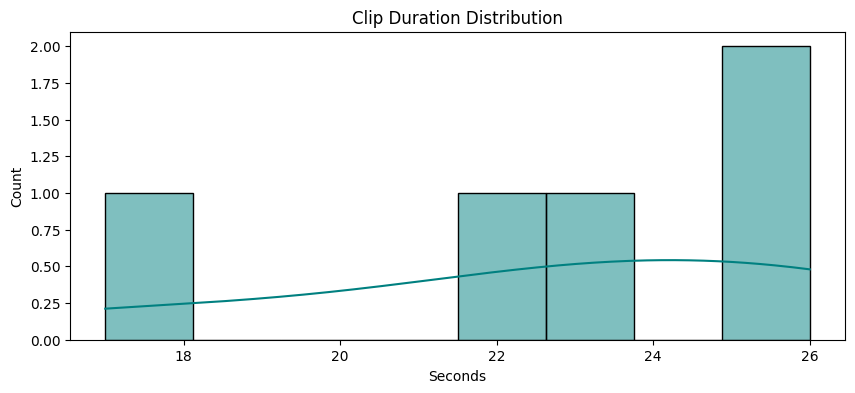

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#   LOad the data
df = pd.read_csv(r'D:\content_generation_system\clips_metadata.csv')

# --- Plot 1: Clip Duration Distribution ---
plt.figure(figsize=(10, 4))
sns.histplot(df['duration'], bins=8, color='teal', kde=True)
plt.title("Clip Duration Distribution")
plt.xlabel("Seconds")
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_5308\294658781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='magma')


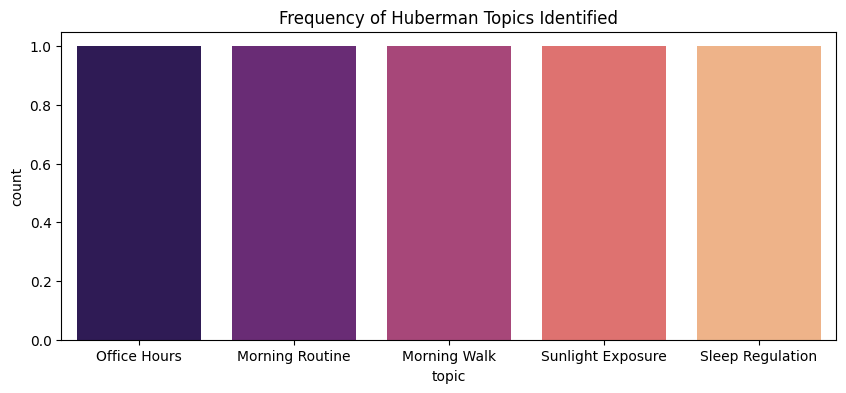

In [9]:
# --- Plot 2: Topic Frequency ---
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='topic', palette='magma')
plt.title("Frequency of Huberman Topics Identified")
plt.show()

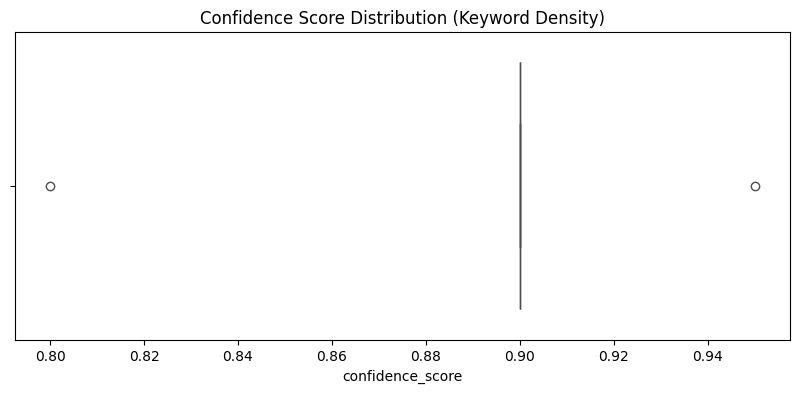

In [10]:
# --- Plot 3: Confidence Score Distribution ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['confidence_score'], color='orange')
plt.title("Confidence Score Distribution (Keyword Density)")
plt.show()

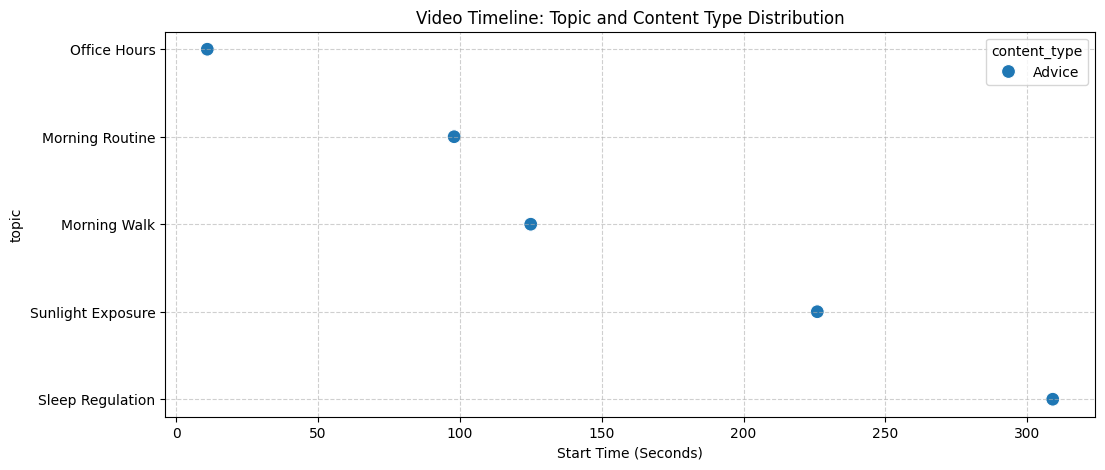

In [ ]:

# --- Plot 4: Timeline visualization of topic shifts in a podcast ---
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='start_time', y='topic', hue='content_type', s=100)
plt.title("Video Timeline: Topic and Content Type Distribution")
plt.xlabel("Start Time (Seconds)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

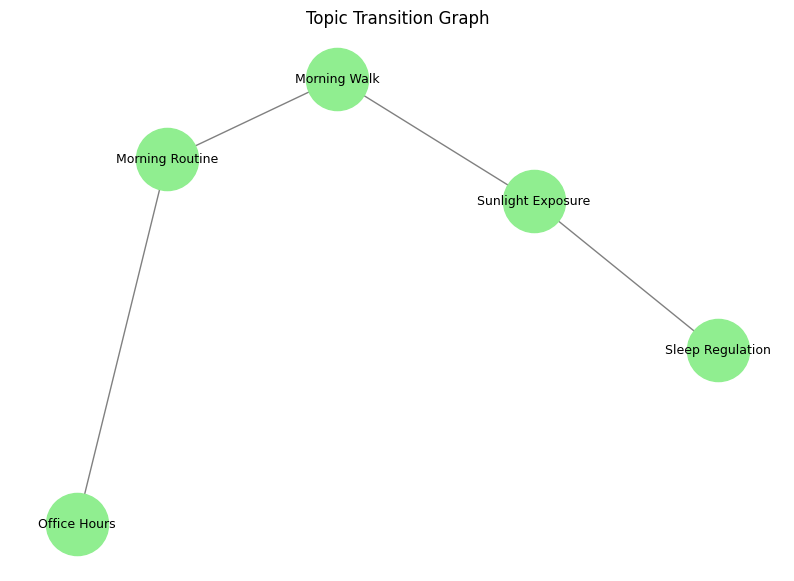

In [18]:
# --- Plot 5: Topic transition graph ---
import networkx as nx
df['next_topic'] = df['topic'].shift(-1)
transitions = df.dropna(subset=['next_topic'])

G = nx.DiGraph()
for _, row in transitions.iterrows():
    G.add_edge(row['topic'], row['next_topic'])

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42) 

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgreen')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Topic Transition Graph")
plt.axis('off')
plt.show()

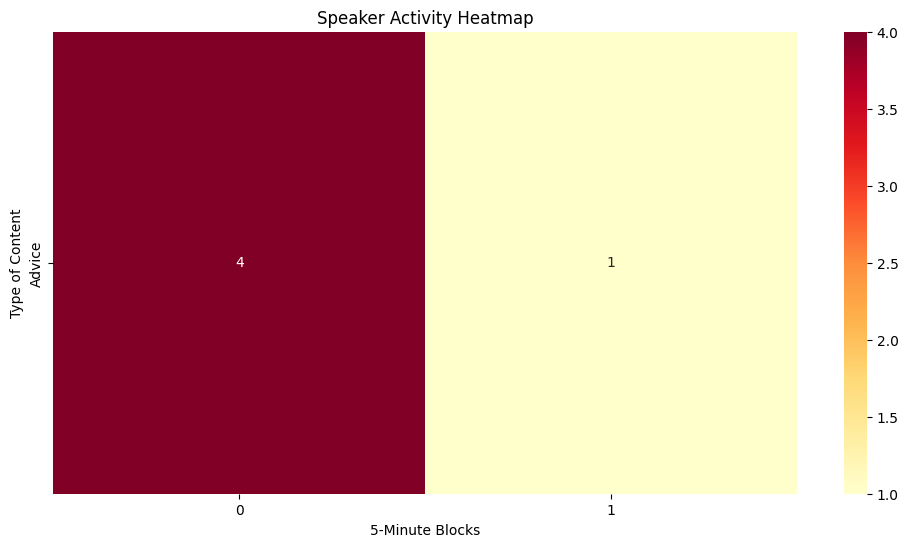

In [ ]:
# --- Plot 6: Speaker contribution heatmap ---
df['time_window'] = (df['start_time'] // 300).astype(int)

heatmap_data = df.pivot_table(index='content_type', 
                             columns='time_window', 
                             values='confidence_score', 
                             aggfunc='count').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd")

plt.title("Speaker Activity Heatmap")
plt.xlabel("5-Minute Blocks")
plt.ylabel("Type of Content")
plt.show()

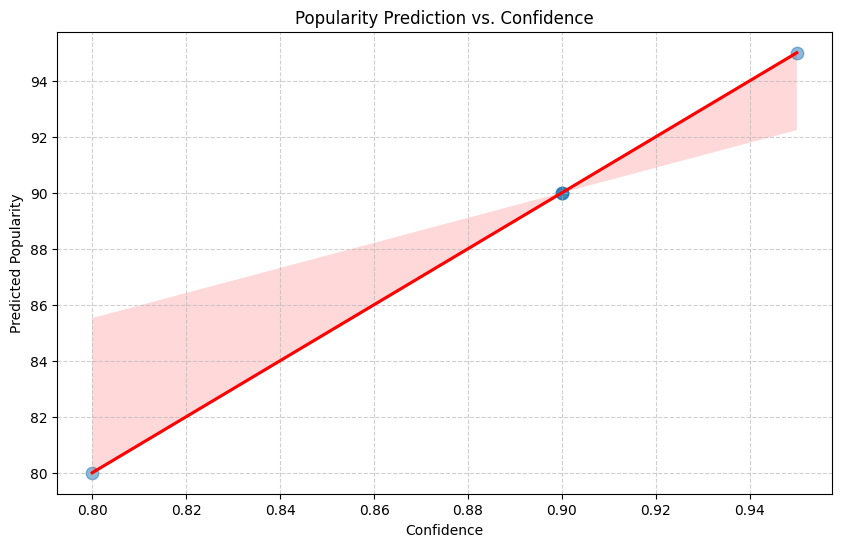

In [22]:
# --- Plot 7: Popularity Prediction vs. Confidence ---
df['predicted_popularity'] = df['confidence_score'] * 100

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='confidence_score', y='predicted_popularity', 
            scatter_kws={'s':80, 'alpha':0.5}, 
            line_kws={'color':'red'})

plt.title("Popularity Prediction vs. Confidence")
plt.xlabel("Confidence")
plt.ylabel("Predicted Popularity")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()